<a href="https://colab.research.google.com/github/chinnumanju18/Chinnu-Manju/blob/main/housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data(): #function definition
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing = load_housing_data()

In [29]:
housing.head()



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [30]:
housing.tail()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [31]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [32]:
housing['ocean_proximity'].value_counts()


,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [33]:
housing.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

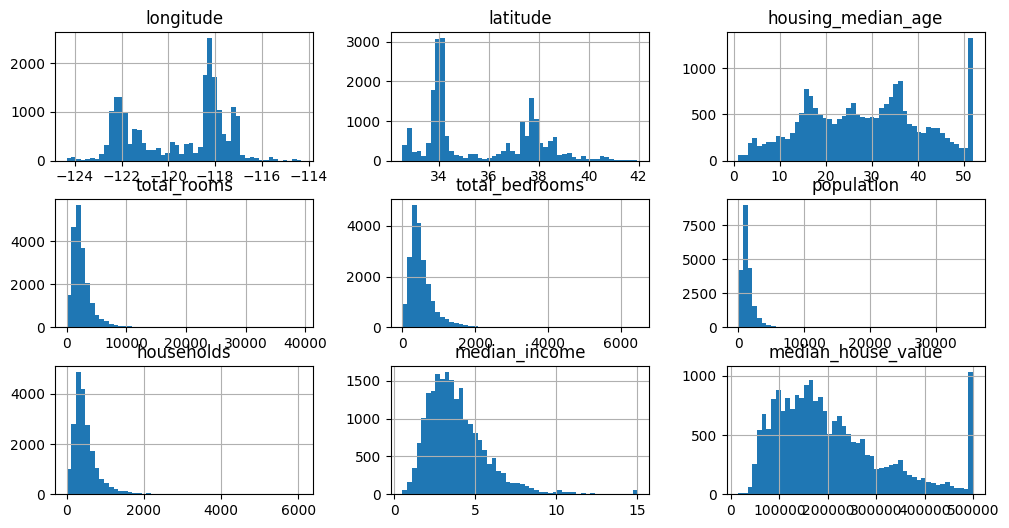

In [34]:
housing.hist(bins=50, figsize=(12,6))


In [35]:
housing['total_rooms'].value_counts()


,count
total_rooms,
1527.0,18
1582.0,17
1613.0,17
2127.0,16
1717.0,15
...,...
7478.0,1
8207.0,1
21533.0,1


In [36]:
housing['total_bedrooms'].value_counts()

,count
total_bedrooms,
280.0,55
331.0,51
345.0,50
343.0,49
393.0,49
...,...
1609.0,1
1591.0,1
2506.0,1


<Axes: xlabel='longitude', ylabel='latitude'>

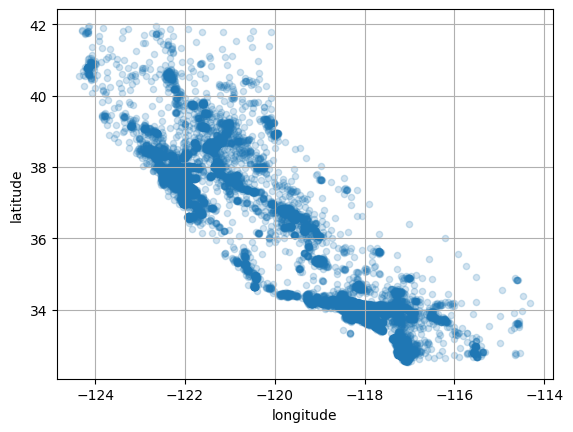

In [37]:
housing.plot(kind='scatter', x='longitude', y='latitude', grid=True,alpha=0.2)

<Axes: xlabel='longitude', ylabel='latitude'>

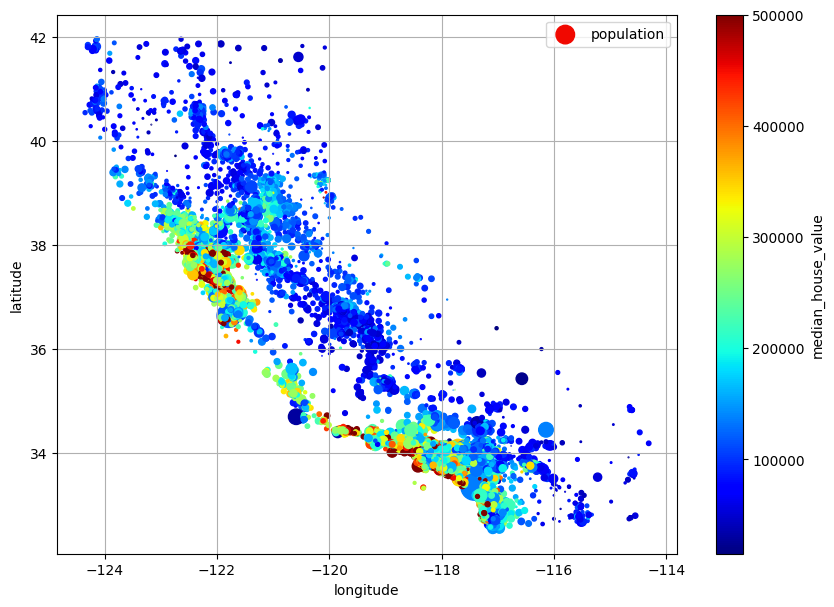

In [38]:
housing.plot(kind = 'scatter',
             x='longitude',
             y='latitude',
             grid =True,
             s=housing['population']/100,
             label='population',
             c='median_house_value',
             cmap='jet',
             colorbar=True,
             legend=True,
             sharex=False,
             figsize=(10,7))

In [39]:
import numpy as np
import pandas as pd

housing['income_cat']= pd.cut(housing['median_income'],bins=[0.,1.5,3.0,4.5,6.,np.inf],labels=[1,2,3,4,5])

from sklearn.model_selection import StratifiedShuffleSplit,train_test_split
splitter = StratifiedShuffleSplit(n_splits=10,test_size=0.2,random_state=40)
strat_splits=[]
for train_index,test_index in splitter.split(housing,housing['income_cat']):
  strat_train_set_n = housing.iloc[train_index]
  strat_test_set_n = housing.iloc[test_index]
  strat_splits.append([strat_train_set_n,strat_test_set_n])
strat_train_set,strat_test_set = strat_splits[0]

strat_train_set,strat_test_set = train_test_split(housing,test_size=0.2,stratify=housing['income_cat'],random_state=40)

for set_ in (strat_train_set,strat_test_set):
  set_.drop(['income_cat'],axis=1,inplace=True)

housing = strat_train_set.copy()
corr_matrix=housing.corr(numeric_only=True)

In [15]:
corr_matrix['median_house_value'].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.689507
total_rooms,0.143696
housing_median_age,0.102001
households,0.073186
total_bedrooms,0.054980
population,-0.017351
longitude,-0.037798
latitude,-0.151781


In [40]:
null_rows_idx=housing.isnull().any(axis=1)
housing.loc[null_rows_idx]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2690,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
16478,-122.00,37.36,17.0,2070.0,NaN,797.0,275.0,8.6155,411200.0,<1H OCEAN
1441,-122.39,37.59,32.0,4497.0,NaN,1846.0,715.0,6.1323,500001.0,NEAR OCEAN
7570,-118.22,34.05,34.0,1113.0,NaN,928.0,290.0,3.1654,155000.0,<1H OCEAN
7701,-118.37,34.03,37.0,1236.0,NaN,966.0,292.0,3.0694,122200.0,<1H OCEAN
...,...,...,...,...,...,...,...,...,...,...
13498,-118.25,33.94,43.0,793.0,NaN,736.0,231.0,0.8527,90400.0,<1H OCEAN
11682,-119.75,36.71,38.0,1481.0,NaN,1543.0,372.0,1.4577,49800.0,INLAND
14935,-122.48,37.70,33.0,4492.0,NaN,3477.0,1537.0,3.0546,297900.0,NEAR OCEAN
15463,-118.31,34.09,37.0,773.0,NaN,835.0,312.0,1.8576,193800.0,<1H OCEAN


In [41]:
#deleting a row and entire column
housing_option1=housing.copy()
housing_option1.dropna(subset=['total_bedrooms'],inplace=True)
housing_option1.loc[null_rows_idx].head()
housing_option2=housing.copy()
housing_option2.drop("total_bedrooms",axis=1, inplace=True)
housing_option2.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value,ocean_proximity
2690,-122.10,37.69,41.0,746.0,387.0,161.0,3.9063,178400.0,NEAR BAY
16478,-122.00,37.36,17.0,2070.0,797.0,275.0,8.6155,411200.0,<1H OCEAN
1441,-122.39,37.59,32.0,4497.0,1846.0,715.0,6.1323,500001.0,NEAR OCEAN
7570,-118.22,34.05,34.0,1113.0,928.0,290.0,3.1654,155000.0,<1H OCEAN
7701,-118.37,34.03,37.0,1236.0,966.0,292.0,3.0694,122200.0,<1H OCEAN


In [42]:
#replacing missing values with median
housing_option3=housing.copy()
median=housing["total_bedrooms"].median()
housing_option3["total_bedrooms"].fillna(median,inplace=True)
housing_option3.loc[null_rows_idx].head()

<ipython-input-42-8b99c95556a3>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing_option3["total_bedrooms"].fillna(median,inplace=True)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2690,-122.10,37.69,41.0,746.0,436.0,387.0,161.0,3.9063,178400.0,NEAR BAY
16478,-122.00,37.36,17.0,2070.0,436.0,797.0,275.0,8.6155,411200.0,<1H OCEAN
1441,-122.39,37.59,32.0,4497.0,436.0,1846.0,715.0,6.1323,500001.0,NEAR OCEAN
7570,-118.22,34.05,34.0,1113.0,436.0,928.0,290.0,3.1654,155000.0,<1H OCEAN
7701,-118.37,34.03,37.0,1236.0,436.0,966.0,292.0,3.0694,122200.0,<1H OCEAN


In [44]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")
housing_num=housing.select_dtypes(include=[np.number])#find out the datatypes that has numbers
imputer.fit(housing_num)
imputer.statistics_

array([-1.1849e+02,  3.4250e+01,  2.9000e+01,  2.1310e+03,  4.3600e+02,
        1.1680e+03,  4.1000e+02,  3.5391e+00,  1.7940e+05])

In [45]:
housing_num.median().values

array([-1.1849e+02,  3.4250e+01,  2.9000e+01,  2.1310e+03,  4.3600e+02,
        1.1680e+03,  4.1000e+02,  3.5391e+00,  1.7940e+05])

In [46]:
x=imputer.transform(housing_num)
imputer.feature_names_in_
housing_tr=pd.DataFrame(x,columns=housing_num.columns,index=housing_num.index)
housing_tr.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
2690,-122.10,37.69,41.0,746.0,436.0,387.0,161.0,3.9063,178400.0
16478,-122.00,37.36,17.0,2070.0,436.0,797.0,275.0,8.6155,411200.0
1441,-122.39,37.59,32.0,4497.0,436.0,1846.0,715.0,6.1323,500001.0
7570,-118.22,34.05,34.0,1113.0,436.0,928.0,290.0,3.1654,155000.0
7701,-118.37,34.03,37.0,1236.0,436.0,966.0,292.0,3.0694,122200.0


array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

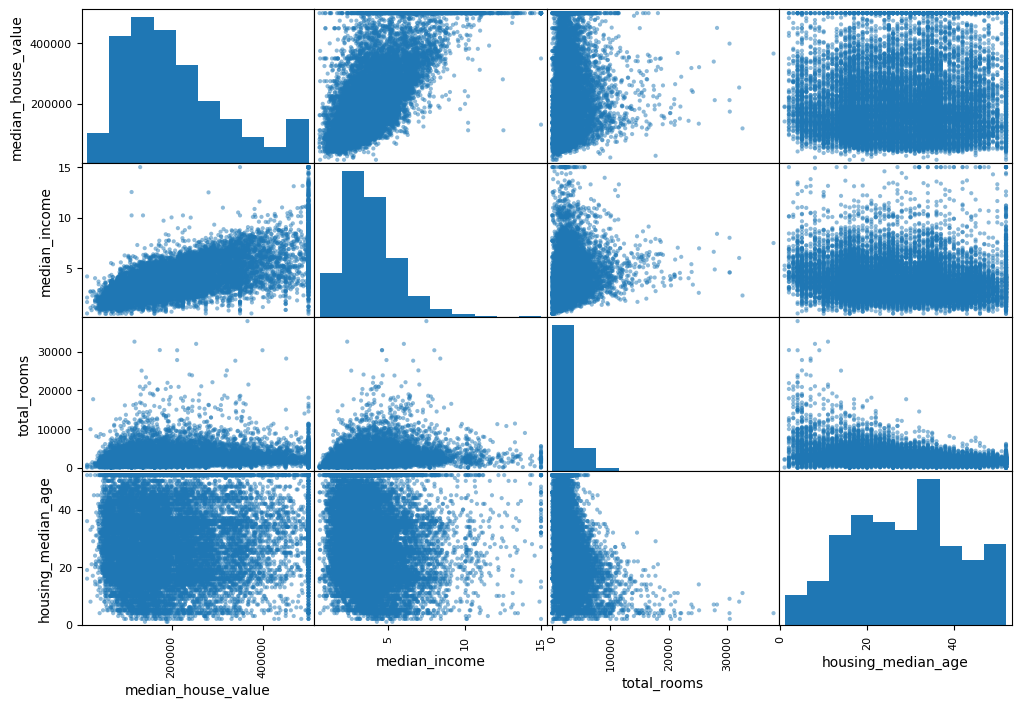

In [47]:
from pandas.plotting import scatter_matrix

attries = ['median_house_value',"median_income","total_rooms",'housing_median_age']
scatter_matrix(housing[attries],figsize=(12,8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

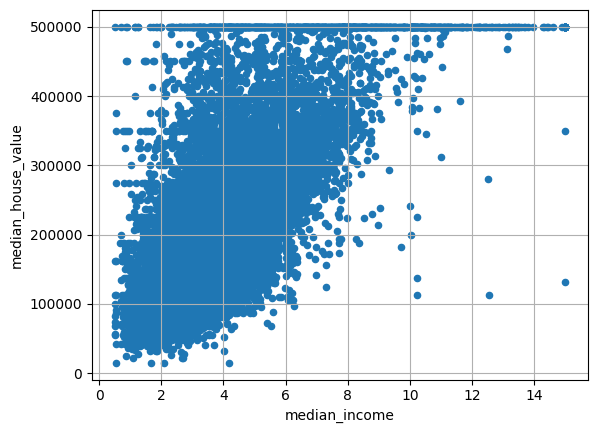

In [49]:
housing.plot(kind="scatter", x="median_income",y="median_house_value",grid=True)